# Streaming

In [13]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch

from typing import Annotated
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display
import uuid

load_dotenv()

True

### Initalize model

In [5]:
## initalize model
model = init_chat_model(
    model = "groq:qwen/qwen3.6-27b"
)

## create state variable
class State(TypedDict):
    # Messages have the type "list", the 'add_messages' function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages in to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


### Persistent memory

In [ ]:
memory = MemorySaver()

### Chatbot Node

In [ ]:
def superbot(state: State):
    return {"messages": [model.invoke(state['messages'])]}

### Graph : with persistent memory

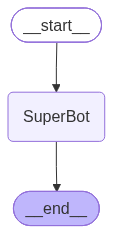

In [11]:
graph = StateGraph(State)

## node
graph.add_node("SuperBot", superbot)

## Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

## display
try:
    display(Image(graph_builder.get_graph().draw_mermaid_png()))
except Exception as e:
    raise e

### Invocation

In [ ]:
config = {"configurable": {"thread_id": str(uuid.uuid4())}}
config

In [16]:
graph_builder.invoke({'messages': "Hi, My name is Rahul and I like badminton"}, config)

{'messages': [HumanMessage(content='Hi, My name is Rahul and I like badminton', additional_kwargs={}, response_metadata={}, id='2a4288f2-4207-48ee-9f13-482960b588a8'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Rahul\n   - Interest: Badminton\n   - Greeting: "Hi"\n   - Tone: Casual, friendly\n\n2.  **Identify Key Elements to Respond To:**\n   - Acknowledge the greeting\n   - Use the name (Rahul)\n   - Acknowledge the interest (badminton)\n   - Keep it friendly and engaging\n   - Optionally ask a follow-up question to continue the conversation\n\n3.  **Draft Response (Mental Refinement):**\n   Hi Rahul! Nice to meet you. That\'s awesome that you like badminton—it\'s such a fast-paced and exciting sport. Do you play competitively, or more for fun? Any favorite players or tournaments you follow?\n\n4.  **Check Against Guidelines:**\n   - Personalized? Yes (uses name, acknowledges interest)\n   - Conversational? Yes\n   - Open-end

- We are seeing above the `HumanMessage` and `AIMessage` (the response), so we are going to learn some streaming techniques, this will be used while building chatbots

## Streaming

Methods: `.stream()` and `astream()`

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values**: This streams the full state of the graph after each node is called.

- **updates**: This streams updates to the state of the graph after each node is called.

### Case 1: `steam_mode` = `"updates"`

In [17]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({"messages": "Hi, My name is Rahul and i like badminton"}, config=config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hi, My name is Rahul and i like badminton"\n   - Key information: Name = Rahul, Interest = Badminton\n   - Tone: Friendly, introductory\n\n2.  **Identify Core Requirements:**\n   - Acknowledge the greeting\n   - Use the name (Rahul)\n   - Acknowledge the interest (badminton)\n   - Keep it friendly and engaging\n   - Optionally ask a follow-up question to continue the conversation\n\n3.  **Formulate Response (Mental Draft):**\n   Hi Rahul! Nice to meet you. Badminton is a fantastic sport—fast-paced, strategic, and great for staying active. Do you play casually with friends, or are you part of a club/league? Also, what\'s your favorite part about playing?\n\n4.  **Refine Response (Check against requirements):**\n   - Greeting? Yes\n   - Uses name? Yes\n   - Acknowledges interest? Yes\n   - Engaging/follow-up? Yes\n   - Tone appropriate? Yes, friendly and c

**conclusion:**
- Current execution AI message , we will not get the human message
- Which ever was the last message, which came from the AI only that is getting displayed

### Case 2: `steam_mode` = `"values"`

In [19]:
for chunk in graph_builder.stream({"messages": "I also like football"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Rahul and i like badminton', additional_kwargs={}, response_metadata={}, id='4f0bfee8-ab70-4429-a425-c3aa1a72c1c1'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hi, My name is Rahul and i like badminton"\n   - Key information: Name = Rahul, Interest = Badminton\n   - Tone: Friendly, introductory\n\n2.  **Identify Core Requirements:**\n   - Acknowledge the greeting\n   - Use the name (Rahul)\n   - Acknowledge the interest (badminton)\n   - Keep it friendly and engaging\n   - Optionally ask a follow-up question to continue the conversation\n\n3.  **Formulate Response (Mental Draft):**\n   Hi Rahul! Nice to meet you. Badminton is a fantastic sport—fast-paced, strategic, and great for staying active. Do you play casually with friends, or are you part of a club/league? Also, what\'s your favorite part about playing?\n\n4.  **Refine Response (Check against requirements):**\n   - 

**conclusion:**

- Here we can see we get 2 time `HumanMessage` appended and reply as `AIMessage`.
- All the conversation basically getting appended/updated.

### Using `astream_event` with `async` 

**Application:**

- If we want much more detailed information just to do debugging w.r.t every sentences 

In [22]:
# Create a thread
config = {"configurable": {"thread_id": "5"}}

async for chunk in graph_builder.astream_events({"messages": "Hi, My name is Rahul and i like badminton"}, config=config, version="v2", stream_mode="updates"):
    print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, My name is Rahul and i like badminton'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a00ac4-fd35-70e1-95d6-6caa5b915690', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Rahul and i like badminton', additional_kwargs={}, response_metadata={}, id='73cdf52a-180e-4b78-b133-d3bb14b95425')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a00ac4-fd3a-7c92-aa12-80235f44b264', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:d4a1015b-ce4a-46d9-f853-49871620e44a'}, 'parent_ids': ['01a00ac4-fd35-70e1-95d6-6caa5b915690']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMess